In [1]:
import numpy as np
import matplotlib.pyplot as plt

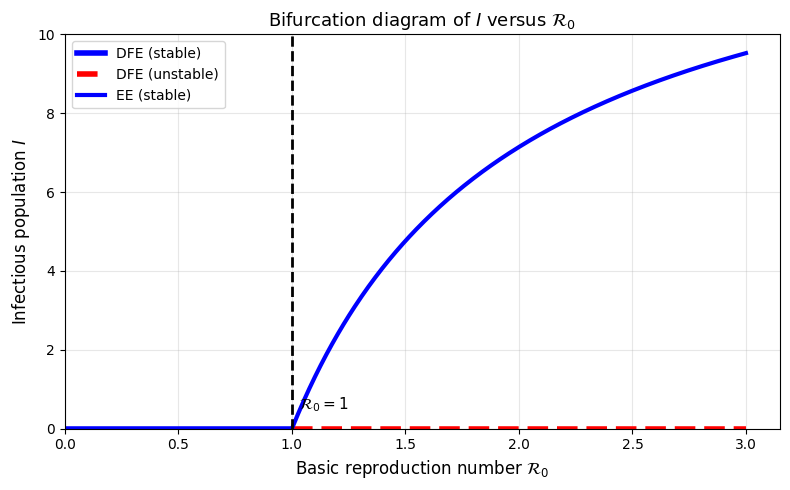

In [2]:
Lambda = 10.0
gamma = 0.4
mu = 0.2
delta = 0.1

R0 = np.linspace(0.0, 3.0, 600)
R0[0] = 1e-6 

I_dfe = np.zeros_like(R0)
I_dfe_stable = np.where(R0 < 1, I_dfe, np.nan)
I_dfe_unstable = np.where(R0 > 1, I_dfe, np.nan)

I_ee = (Lambda / (gamma + mu + delta)) * (1 - 1 / R0)
I_ee_feasible = np.where(R0 > 1, I_ee, np.nan)

plt.figure(figsize=(8, 5))

plt.plot(
    R0, I_dfe_stable,
    color='blue',
    linewidth=4,
    label="DFE (stable)"
)

plt.plot(
    R0, I_dfe_unstable,
    color='red',
    linestyle='--',
    linewidth=4,
    label="DFE (unstable)"
)

plt.plot(
    R0, I_ee_feasible,
    color='blue',
    linewidth=3,
    label="EE (stable)"
)

plt.axvline(x=1, color='black', linestyle='--', linewidth=2)
plt.text(1.03, 0.5, r"$\mathcal{R}_0 = 1$", fontsize=11)
plt.xlabel(r"Basic reproduction number $\mathcal{R}_0$", fontsize=12)
plt.ylabel(r"Infectious population $I$", fontsize=12)
plt.title(r"Bifurcation diagram of $I$ versus $\mathcal{R}_0$", fontsize=13)
# plt.annotate(
#     r"$E_0 = E^*$",
#     xy=(1, 0),
#     xytext=(1.2, 1.0),
#     arrowprops=dict(arrowstyle="->"),
#     fontsize=11
# )
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("bifurcation.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation of the bifurcation diagram

The bifurcation diagram shows how the long-term behavior of the disease changes as the basic reproduction number $\mathcal{R}_0$ varies.

When $\mathcal{R}_0 < 1$, each infected individual produces less than one new infection on average, so the disease dies out and the population converges to a disease-free state.

At $\mathcal{R}_0 = 1$, the system reaches a critical threshold where the disease is at the boundary between extinction and persistence, and the disease-free and endemic states coincide.

When $\mathcal{R}_0 > 1$, the disease persists in the population, leading to a stable endemic state with a positive number of infected individuals.

This diagram highlights the crucial role of $\mathcal{R}_0$ as a threshold: keeping it below one ensures disease elimination, while values above one lead to sustained transmission.